In [2]:
import pandas as pd

titanic_df = pd.read_csv("encoded_titanic_dataset.csv")

titanic_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,2,22.0,1,0,7.2500,0,0,1,0,0,1
1,2,1,0,38.0,1,0,71.2833,1,1,0,1,0,0
2,3,1,2,26.0,0,0,7.9250,0,1,0,0,0,1
3,4,1,0,35.0,1,0,53.1000,1,1,0,0,0,1
4,5,0,2,35.0,0,0,8.0500,0,0,1,0,0,1


Handling data normalization

## Min-Max normalization
this method scales data to fix range typically between 0 and 1.

In [3]:
min_fare = titanic_df.Fare.min()
max_fare = titanic_df.Fare.max()

In [4]:
norm_fare = ( titanic_df.Fare - min_fare) / ( max_fare - min_fare )

<Axes: ylabel='Density'>

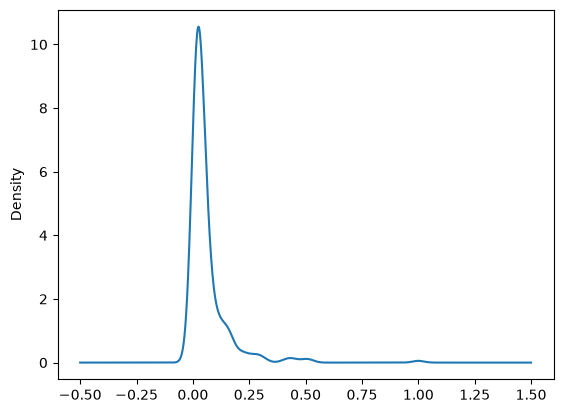

In [5]:
norm_fare.plot(kind = "kde")

<Axes: ylabel='Density'>

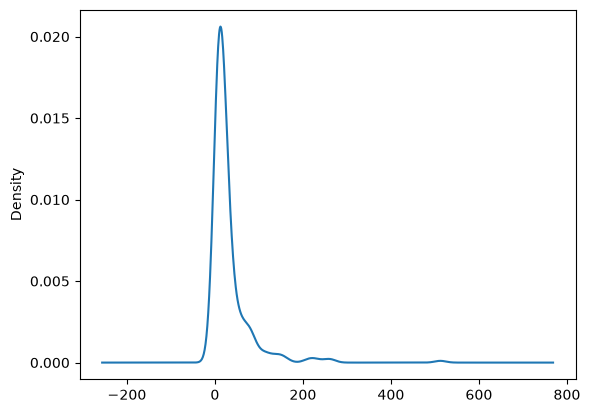

In [6]:
titanic_df.Fare.plot(kind = "kde")

In [7]:

# Sklearn
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()

scaled_data = mm_scaler.fit_transform(titanic_df[["Fare"]])

In [8]:
scaled_data

array([[0.01415106],
       [0.13913574],
       [0.01546857],
       [0.1036443 ],
       [0.01571255],
       [0.0165095 ],
       [0.10122886],
       [0.04113566],
       [0.02173075],
       [0.05869429],
       [0.03259623],
       [0.05182215],
       [0.01571255],
       [0.06104473],
       [0.01533038],
       [0.03122992],
       [0.05684821],
       [0.02537431],
       [0.03513366],
       [0.01410226],
       [0.05074862],
       [0.02537431],
       [0.01567195],
       [0.06929139],
       [0.04113566],
       [0.06126432],
       [0.01410226],
       [0.51334181],
       [0.01537917],
       [0.01541158],
       [0.0541074 ],
       [0.28598956],
       [0.01512699],
       [0.16038672],
       [0.10149724],
       [0.01411046],
       [0.01571255],
       [0.03513366],
       [0.02194234],
       [0.01849397],
       [0.04098927],
       [0.01541158],
       [0.08115719],
       [0.01537917],
       [0.01571255],
       [0.03025399],
       [0.01512699],
       [0.042

##  Z-Score Normalization

In [12]:
mean_fare = titanic_df.Fare.mean()
std_fare = titanic_df.Fare.std()

In [13]:
norm_fare = (titanic_df.Fare - mean_fare) / std_fare

In [14]:
norm_fare.describe()

count    874.000000
mean       0.000000
std        1.000000
min       -0.644598
25%       -0.484813
50%       -0.352092
75%       -0.024407
max        9.723254
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

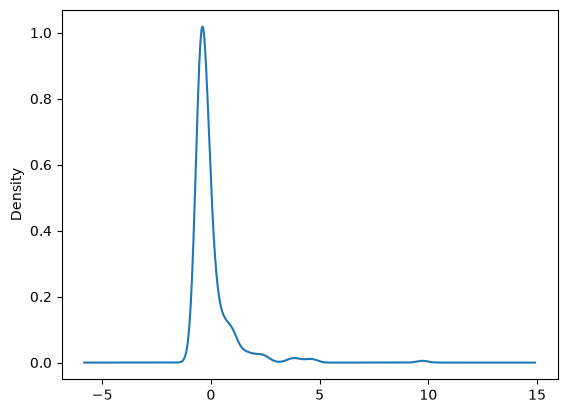

In [15]:
norm_fare.plot(kind = "kde")

In [16]:
# sklearn
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

In [17]:
norm_data = std_scaler.fit_transform(titanic_df)

In [18]:
pd.DataFrame(norm_data, columns=titanic_df.columns)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,-1.734376,-0.792187,0.816817,-0.542976,0.423479,-0.476412,-0.498167,-0.535898,-0.741381,0.741381,-0.482413,-0.306378,0.615263
1,-1.730484,1.262328,-1.595000,0.757822,0.423479,-0.476412,0.798398,1.866026,1.348835,-1.348835,2.072913,-0.306378,-1.625320
2,-1.726591,1.262328,0.816817,-0.217777,-0.477058,-0.476412,-0.484499,-0.535898,1.348835,-1.348835,-0.482413,-0.306378,0.615263
3,-1.722699,1.262328,-1.595000,0.513922,0.423479,-0.476412,0.430217,1.866026,1.348835,-1.348835,-0.482413,-0.306378,0.615263
4,-1.718807,-0.792187,0.816817,0.513922,-0.477058,-0.476412,-0.481968,-0.535898,-0.741381,0.741381,-0.482413,-0.306378,0.615263
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,1.714282,-0.792187,-0.389092,-0.136477,-0.477058,-0.476412,-0.381739,-0.535898,-0.741381,0.741381,-0.482413,-0.306378,0.615263
870,1.718174,1.262328,-1.595000,-0.786876,-0.477058,-0.476412,-0.037518,1.866026,1.348835,-1.348835,-0.482413,-0.306378,0.615263
871,1.722067,-0.792187,0.816817,-0.624276,0.423479,2.016907,-0.170144,-0.535898,1.348835,-1.348835,-0.482413,-0.306378,0.615263
872,1.725959,1.262328,-1.595000,-0.217777,-0.477058,-0.476412,-0.037518,1.866026,-0.741381,0.741381,2.072913,-0.306378,-1.625320


## Log Transformation

<Axes: >

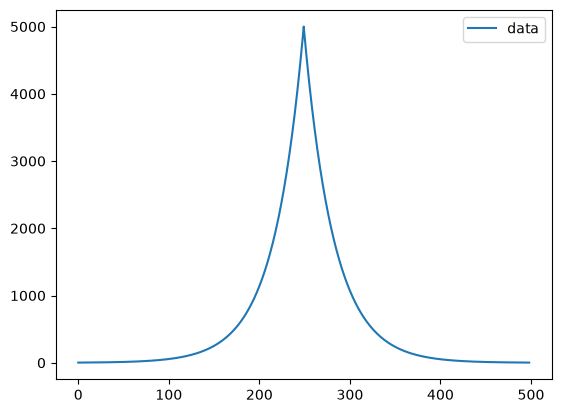

In [19]:
import numpy as np

peak = 5 * 10e2   # 500000
n = 250            # points per side

k = np.log(peak)
growth = np.exp(np.linspace(1, k, n))
decay = np.exp(np.linspace(k, 1, n))
data = np.concatenate([growth, decay[1:]])

pd.DataFrame(data, columns=["data"]).plot(kind = "line")

<Axes: >

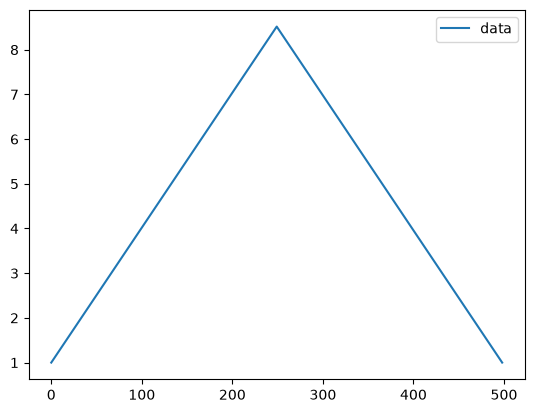

In [20]:
pd.DataFrame(np.log(data), columns=["data"]).plot(kind = "line")

## Power Transformation

<Axes: ylabel='Density'>

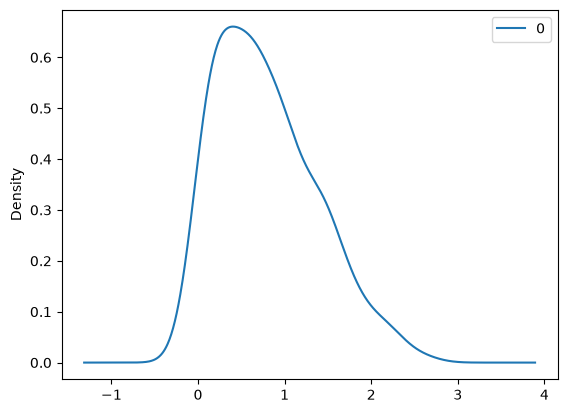

In [21]:
from scipy.stats import skewnorm

data = pd.DataFrame(skewnorm.rvs(25, size = 200))

data.plot.kde()

In [22]:
pow_transformer = lambda series, pow_factor : np.sign(series) * np.power(np.abs(series) , pow_factor)

In [23]:
trans_data = pow_transformer(data, 0.5)

<Axes: ylabel='Density'>

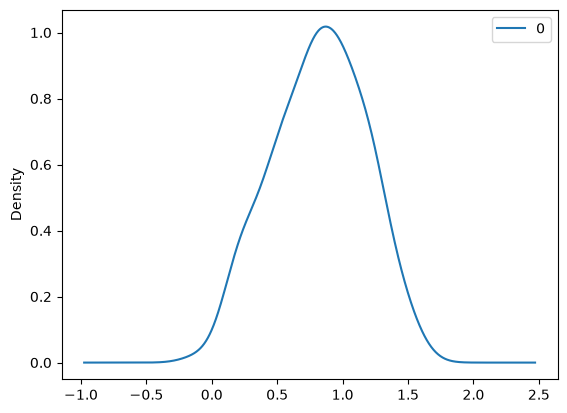

In [24]:
trans_data.plot.kde()